In [1]:
%pip install optuna xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import random # 난수 생성을 위한 라이브러리 불러오기
import os # 경로 설정을 위한 운영체제 라이브러리 불러오기

import pandas as pd # Pandas 라이브러리 불러오기
import numpy as np # Numpy 라이브러리 불러오기

import matplotlib.pyplot as plt # 그래프 시각화를 위한 라이브러리 불러오기
import seaborn as sns # 그래프 시각화를 위한 라이브러리 불러오기
import koreanize_matplotlib # 그래프 한글 폰트 설정을 위한 라이브러리 불러오기
import matplotlib.colors as mcolors
from matplotlib import cm

from sklearn.model_selection import train_test_split, KFold # 데이터 분할과 K-Fold 교차 검증을 위한 라이브러리 불러오기
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.pipeline import Pipeline # 머신러닝 파이프라인 구축을 위한 라이브러리 불러오기 
from sklearn.compose import ColumnTransformer # 열 변환을 위한 라이브러리 불러오기
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder # 데이터 전처리를 위한 라이브러리 불러오기
from sklearn.metrics import mean_absolute_error, mean_squared_error # 모델 평가를 위한 라이브러리 불러오기
import optuna # 하이퍼파라미터 튜닝을 위한 라이브러리 불러오기
from sklearn.ensemble import VotingRegressor # 앙상블 모델을 위한 라이브러리 불러오기
from sklearn.base import BaseEstimator, RegressorMixin 
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

import joblib # 모델 저장을 위한 라이브러리 불러오기
import os # 모델 저장 경로 설정을 위한 라이브러리 불러오기

import warnings
# 경고 무시 (깔끔한 출력을 위해)
warnings.filterwarnings('ignore', category=UserWarning)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Fixed RandomSeed / 랜덤시드 고정
매번 고정된 결과를 얻기 위해서 사용합니다.  

seed를 고정하지 않는다면 같은 코드라도 매번 다른 결과가 나오게됩니다.  

항상 동일한 결과를 얻기 위해서 사용합니다.

In [3]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

# 수직선 출력 
데이터를 여러 줄에 걸쳐 출력해야 할 경우, 
각 문단에 수직선을 사용하여 가독성을 높이도록 합니다.

In [4]:
def print_divider(cnt=120):
    print('-' * cnt)

# Data Load / 데이터 불러오기

In [5]:
train = pd.read_csv('data/train.csv') # 학습 데이터 불러오기
test = pd.read_csv('data/test.csv') # 테스트 데이터 불러오기

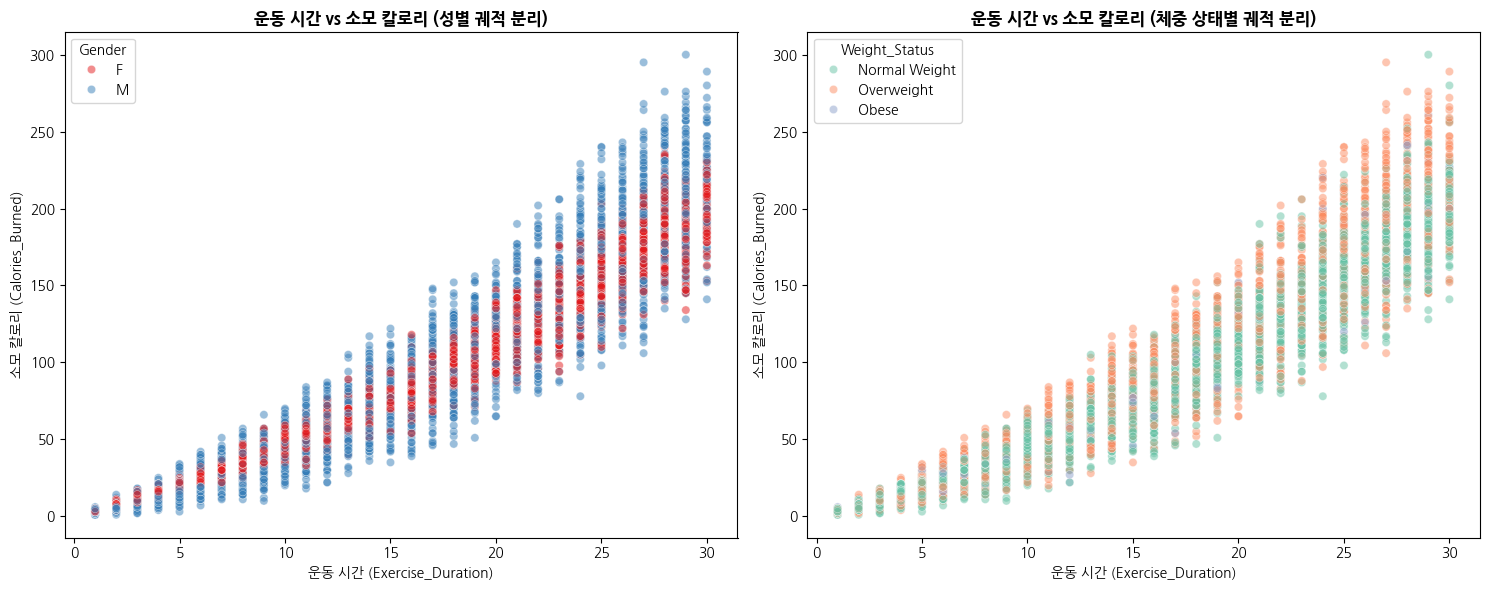

In [134]:
# 도화지 세팅 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 성별(Gender)에 따른 궤적 분리 산점도
sns.scatterplot(
    data=train, 
    x='Exercise_Duration', 
    y='Calories_Burned', 
    hue='Gender', 
    palette='Set1',
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('운동 시간 vs 소모 칼로리 (성별 궤적 분리)', fontweight='bold')
axes[0].set_xlabel('운동 시간 (Exercise_Duration)')
axes[0].set_ylabel('소모 칼로리 (Calories_Burned)')

# 2. 체중 상태(Weight_Status)에 따른 궤적 분리 산점도
sns.scatterplot(
    data=train, 
    x='Exercise_Duration', 
    y='Calories_Burned', 
    hue='Weight_Status', 
    palette='Set2', 
    alpha=0.5, 
    ax=axes[1]
)
axes[1].set_title('운동 시간 vs 소모 칼로리 (체중 상태별 궤적 분리)', fontweight='bold')
axes[1].set_xlabel('운동 시간 (Exercise_Duration)')
axes[1].set_ylabel('소모 칼로리 (Calories_Burned)')

# 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

# Analyze Train / 학습 데이터 확인하기

In [6]:
print("학습 데이터 크기:", train.shape) # 학습 데이터 크기 출력

print_divider()

# 학습 데이터 명세 출력
print("학습 데이터 명세:")
print(train.info()) 

print_divider()

# 상위 3개 데이터 출력
print("학습 데이터 상위 3개:")
display(train.head(3)) 

학습 데이터 크기: (7500, 11)
------------------------------------------------------------------------------------------------------------------------
학습 데이터 명세:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7500 non-null   object 
 1   Exercise_Duration         7500 non-null   float64
 2   Body_Temperature(F)       7500 non-null   float64
 3   BPM                       7500 non-null   float64
 4   Height(Feet)              7500 non-null   float64
 5   Height(Remainder_Inches)  7500 non-null   float64
 6   Weight(lb)                7500 non-null   float64
 7   Weight_Status             7500 non-null   object 
 8   Gender                    7500 non-null   object 
 9   Age                       7500 non-null   int64  
 10  Calories_Burned           7500 non-null   float64
dtypes: float64(7), int6

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0


In [7]:
print("테스트 데이터 크기:", test.shape) # 테스트 데이터 크기 출력

print_divider()

# 테스트 데이터 명세 출력
print("테스트 데이터 명세:")
print(test.info()) 

print_divider()

# 상위 3개 데이터 출력
print("테스트 데이터 상위 3개:")
display(test.head(3)) 

테스트 데이터 크기: (7500, 10)
------------------------------------------------------------------------------------------------------------------------
테스트 데이터 명세:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7500 non-null   object 
 1   Exercise_Duration         7500 non-null   float64
 2   Body_Temperature(F)       7500 non-null   float64
 3   BPM                       7500 non-null   float64
 4   Height(Feet)              7500 non-null   float64
 5   Height(Remainder_Inches)  7500 non-null   float64
 6   Weight(lb)                7500 non-null   float64
 7   Weight_Status             7500 non-null   object 
 8   Gender                    7500 non-null   object 
 9   Age                       7500 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 586.1+ KB
None
--------

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age
0,TEST_0000,26.0,105.1,107.0,5.0,1.0,114.6,Normal Weight,F,45
1,TEST_0001,29.0,104.9,111.0,6.0,2.0,198.4,Overweight,M,21
2,TEST_0002,11.0,104.0,90.0,5.0,9.0,169.8,Normal Weight,M,58


# Histogram / 연속형 변수의 분포를 막대 그래프로 확인하기
연속된 값을 적당한 구간으로 나누고,  
그 구간에 속하는 데이터의 개수를 세어 막대로 표현합니다.

In [8]:
def plot_histogram(df, col, title='', bins=30, figsize=(6, 4), color='skyblue'):
    plt.figure(figsize=figsize)
    
    sns.histplot(data=df, x=col, bins=bins, kde=True, color=color)
    
    plt.title(title, fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(col, fontsize=10, fontweight='bold')
    plt.ylabel('개수', fontsize=10, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

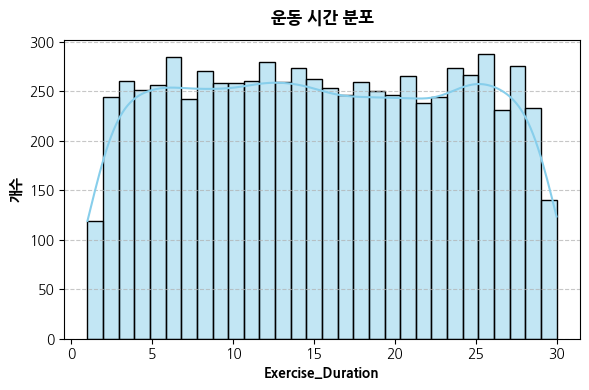

In [9]:
plot_histogram(df=train, col='Exercise_Duration', title='운동 시간 분포', bins=30)

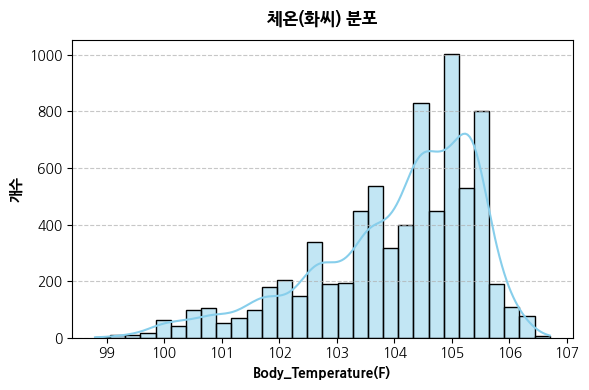

In [10]:
plot_histogram(df=train, col='Body_Temperature(F)', title='체온(화씨) 분포', bins=30)

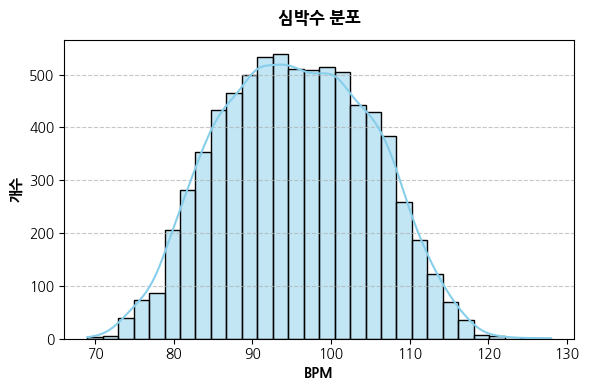

In [11]:
plot_histogram(df=train, col='BPM', title='심박수 분포', bins=30)

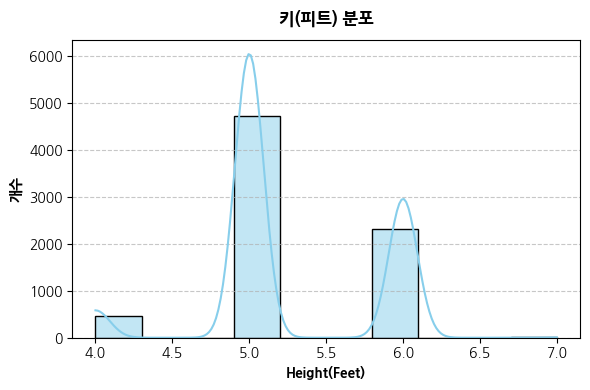

In [12]:
plot_histogram(df=train, col='Height(Feet)', title='키(피트) 분포', bins=10)

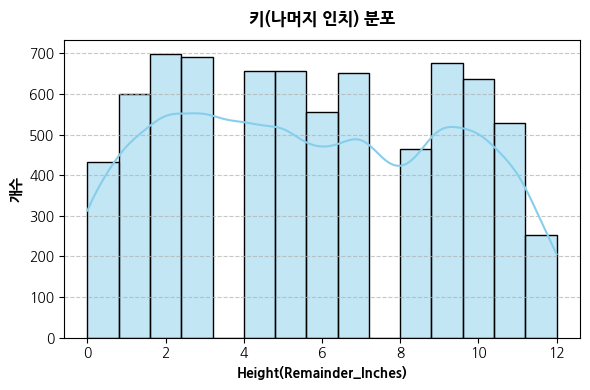

In [13]:
plot_histogram(df=train, col='Height(Remainder_Inches)', title='키(나머지 인치) 분포', bins=15)

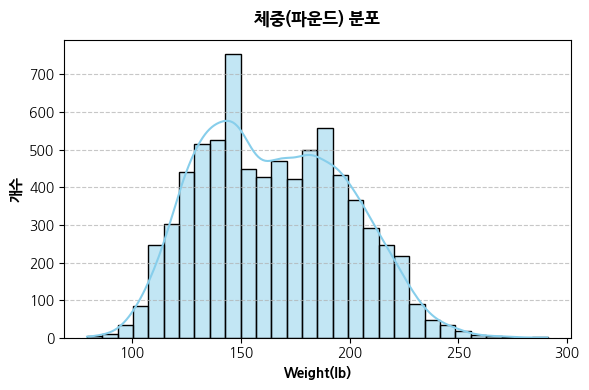

In [14]:
plot_histogram(df=train, col='Weight(lb)', title='체중(파운드) 분포', bins=30)

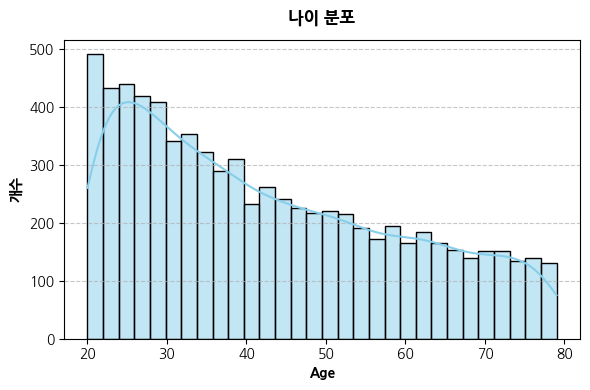

In [15]:
plot_histogram(df=train, col='Age', title='나이 분포', bins=30)

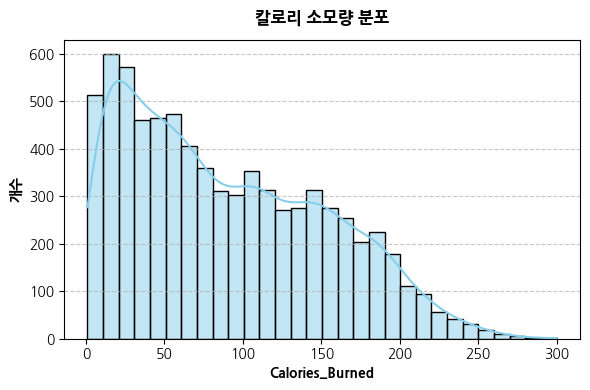

In [16]:
plot_histogram(df=train, col='Calories_Burned', title='칼로리 소모량 분포', bins=30)

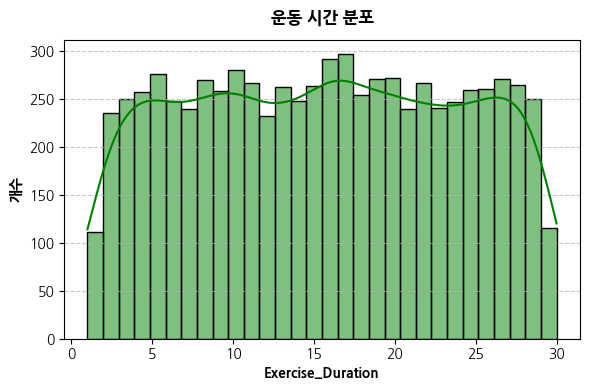

In [17]:
plot_histogram(df=test, col='Exercise_Duration', title='운동 시간 분포', bins=30, color='green')

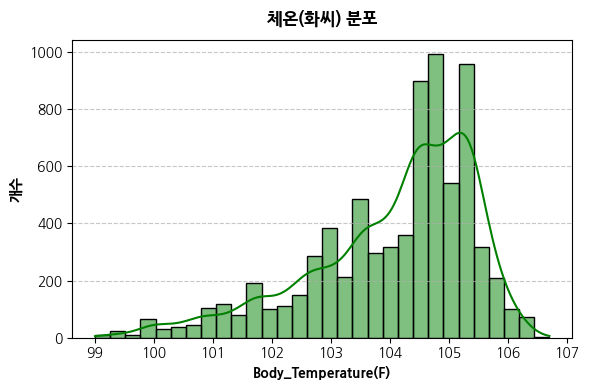

In [18]:
plot_histogram(df=test, col='Body_Temperature(F)', title='체온(화씨) 분포', bins=30, color='green')

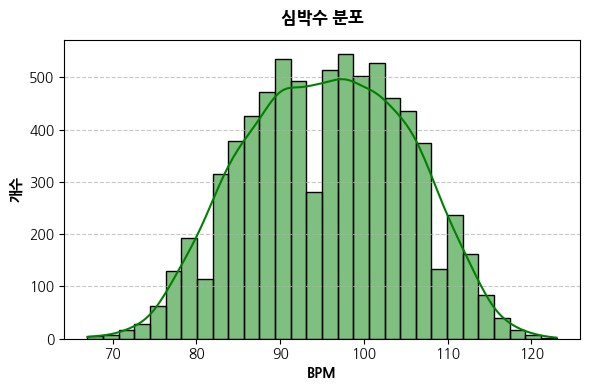

In [19]:
plot_histogram(df=test, col='BPM', title='심박수 분포', bins=30, color='green')

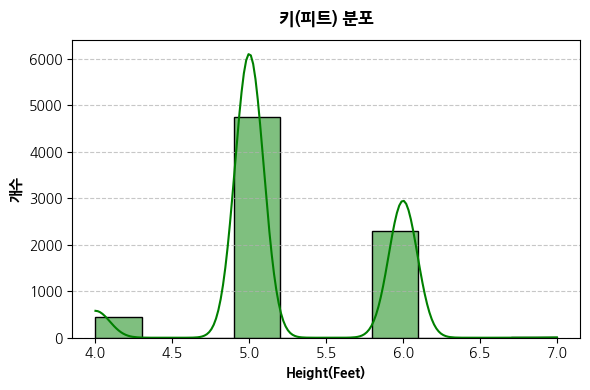

In [20]:
plot_histogram(df=test, col='Height(Feet)', title='키(피트) 분포', bins=10, color='green')

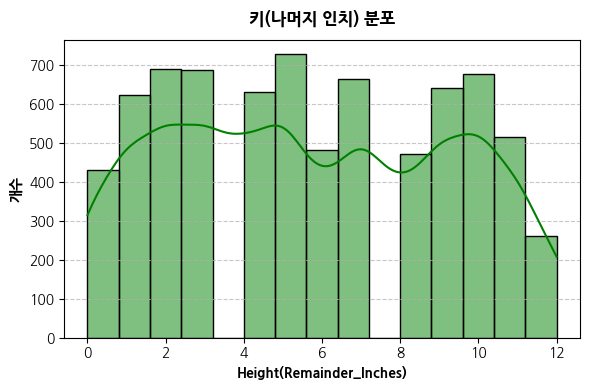

In [21]:
plot_histogram(df=test, col='Height(Remainder_Inches)', title='키(나머지 인치) 분포', bins=15, color='green')

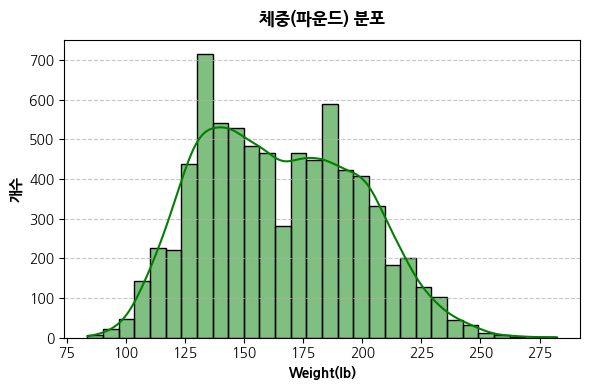

In [22]:
plot_histogram(df=test, col='Weight(lb)', title='체중(파운드) 분포', bins=30, color='green')

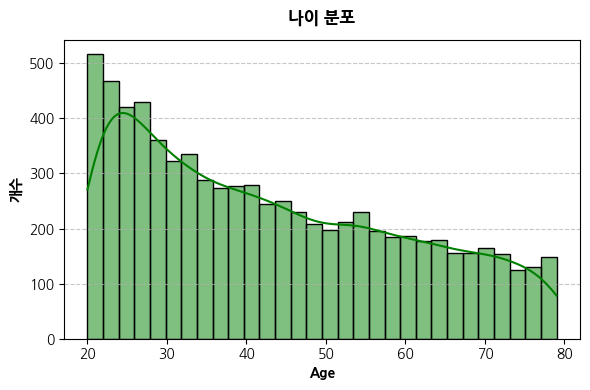

In [23]:
plot_histogram(df=test, col='Age', title='나이 분포', bins=30, color='green')

# Boxplot / 연속형 변수의 분포를 박스 플롯으로 확인하기
데이터의 범위와 이상치를 상자 형태로 나타냅니다.


In [24]:
def plot_boxplot(df, col, x_col=None, title='', figsize=(6, 4), color='skyblue', palette=None, order=None):
    plt.figure(figsize=figsize)
    
    if x_col:
        if order is None:
            plot_order = df[x_col].unique()
        else:
            plot_order = order
            
        # 2. 그래프 그릴 때 plot_order 지정
        ax = sns.boxplot(data=df, x=x_col, y=col, hue=x_col, palette=palette, legend=False, order=plot_order)
        plt.xlabel(x_col, fontsize=10, fontweight='bold')
        
        # 3. 중앙값 계산 후 plot_order에 맞춰 재정렬 (reindex)
        medians = df.groupby(x_col)[col].median().reindex(plot_order)
        
        for i, label in enumerate(plot_order):
            median_val = medians[label]
            
            # 중앙값이 NaN인 경우 방지
            if pd.notna(median_val):
                plt.text(i, median_val, f'{median_val:.2f}', 
                         ha='center', va='center', 
                         color='black', fontweight='bold',
                         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.2'))
    else:
        ax = sns.boxplot(data=df, y=col, color=color)
        
        median_val = df[col].median()
        plt.text(0, median_val, f'{median_val:.2f}', 
                 ha='center', va='center', 
                 color='black', fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.2'))

    plt.title(title, fontsize=12, fontweight='bold', pad=12)
    plt.ylabel(col, fontsize=10, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

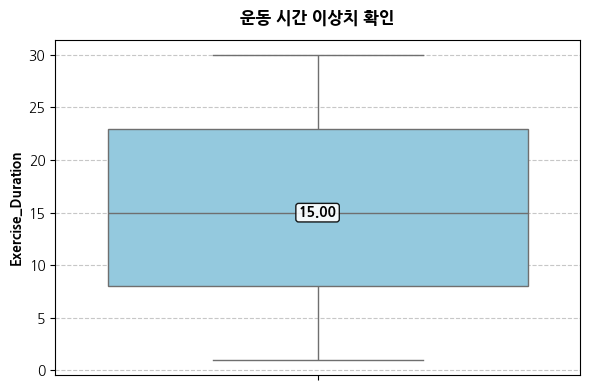

In [25]:
plot_boxplot(train, 'Exercise_Duration', title='운동 시간 이상치 확인')

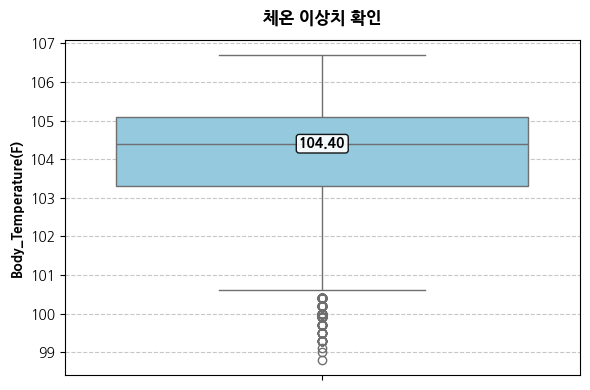

In [26]:
plot_boxplot(train, 'Body_Temperature(F)', title='체온 이상치 확인')

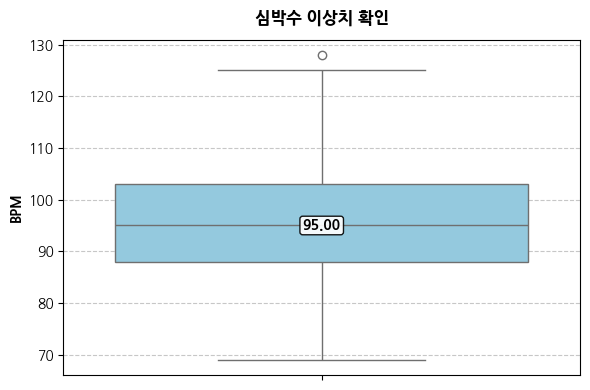

In [27]:
plot_boxplot(train, 'BPM', title='심박수 이상치 확인')

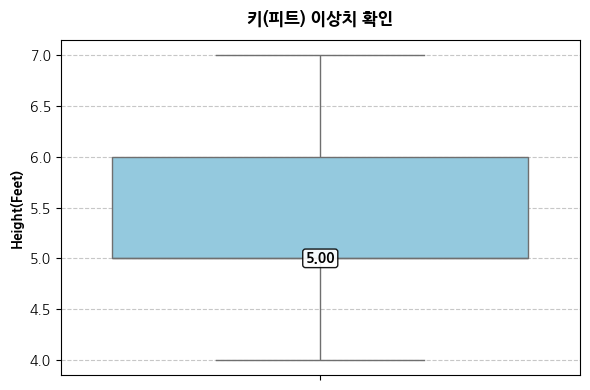

In [28]:
plot_boxplot(train, 'Height(Feet)', title='키(피트) 이상치 확인')

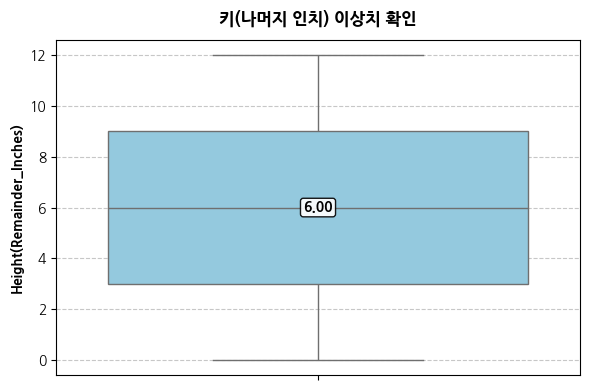

In [29]:
plot_boxplot(train, 'Height(Remainder_Inches)', title='키(나머지 인치) 이상치 확인')

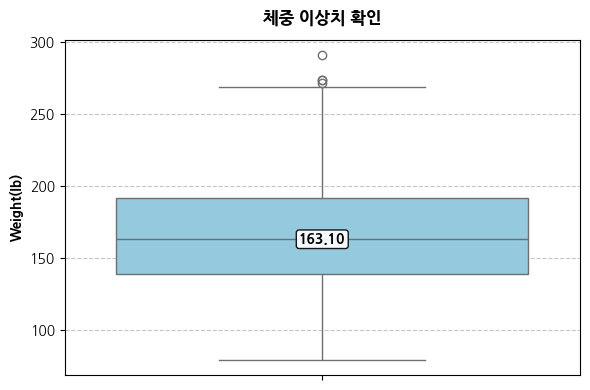

In [30]:
plot_boxplot(train, 'Weight(lb)', title='체중 이상치 확인')

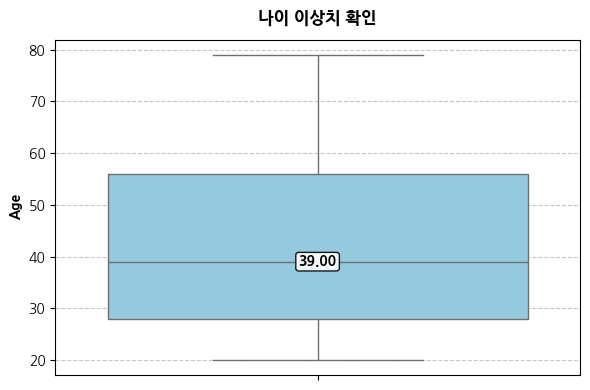

In [31]:
plot_boxplot(train, 'Age', title='나이 이상치 확인')

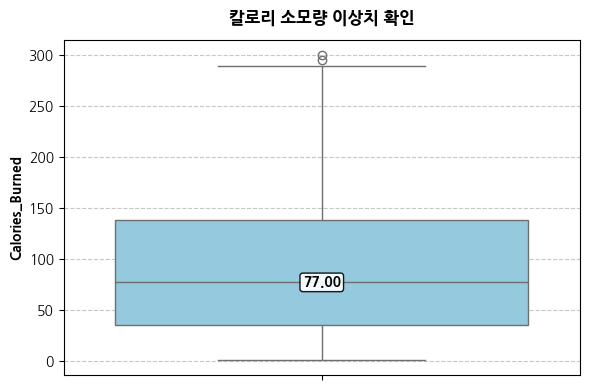

In [32]:
plot_boxplot(train, 'Calories_Burned', title='칼로리 소모량 이상치 확인')

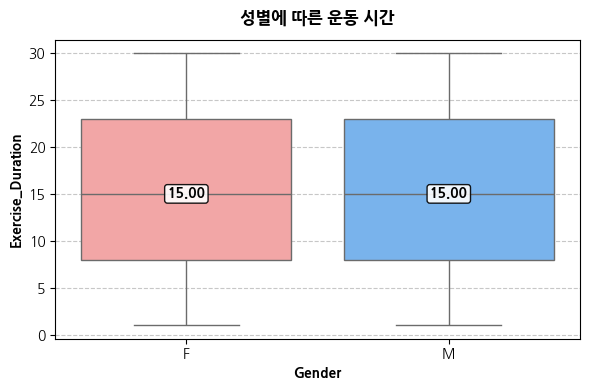

In [33]:
plot_boxplot(train, col='Exercise_Duration', x_col='Gender', 
             title='성별에 따른 운동 시간', 
             palette=['#ff9999', '#66b3ff'])

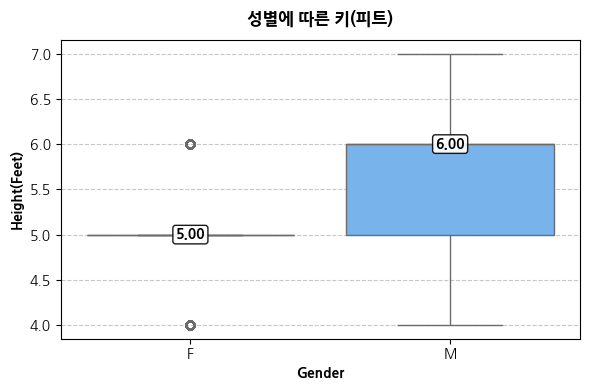

In [34]:
plot_boxplot(train, col='Height(Feet)', x_col='Gender', 
             title='성별에 따른 키(피트)', 
             palette=['#ff9999', '#66b3ff'])

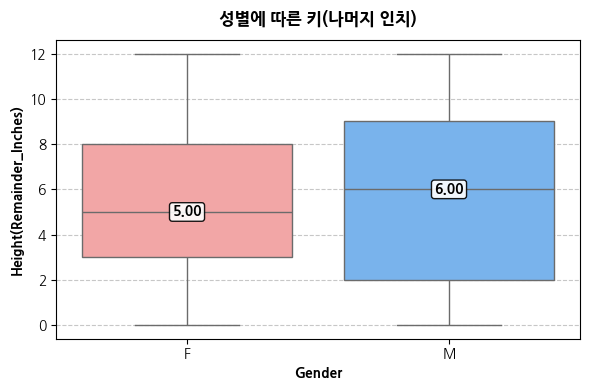

In [35]:
plot_boxplot(train, col='Height(Remainder_Inches)', x_col='Gender', 
             title='성별에 따른 키(나머지 인치)', 
             palette=['#ff9999', '#66b3ff'])

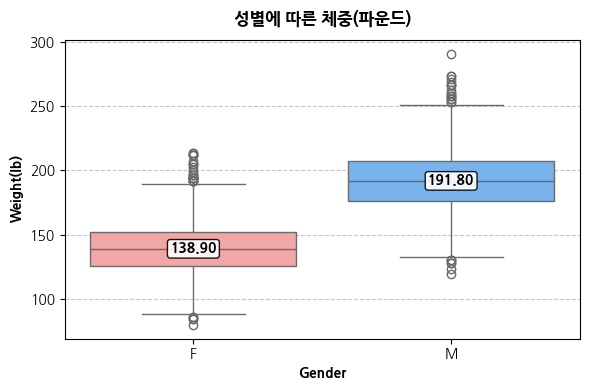

In [36]:
plot_boxplot(train, col='Weight(lb)', x_col='Gender', 
             title='성별에 따른 체중(파운드)', 
             palette=['#ff9999', '#66b3ff']
)

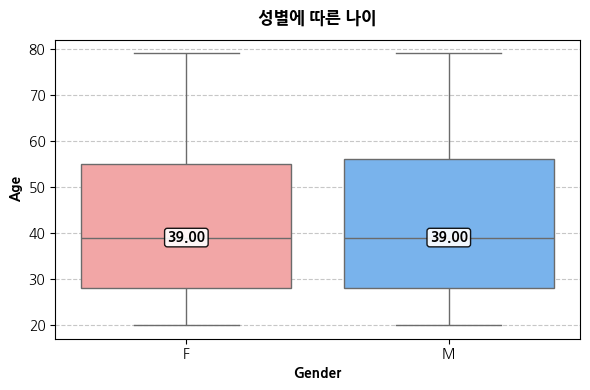

In [37]:
plot_boxplot(train, col='Age', x_col='Gender', 
             title='성별에 따른 나이', 
             palette=['#ff9999', '#66b3ff'])

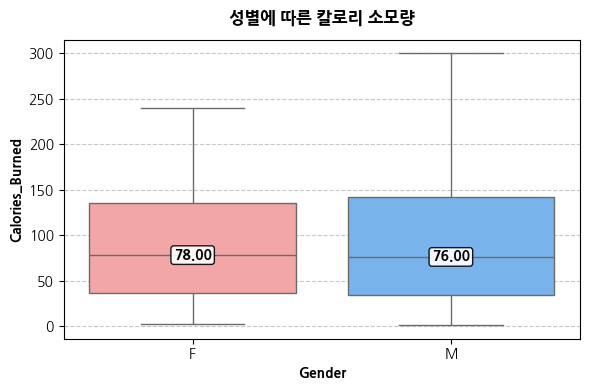

In [38]:
plot_boxplot(train, col='Calories_Burned', x_col='Gender', 
             title='성별에 따른 칼로리 소모량', 
             palette=['#ff9999', '#66b3ff'])

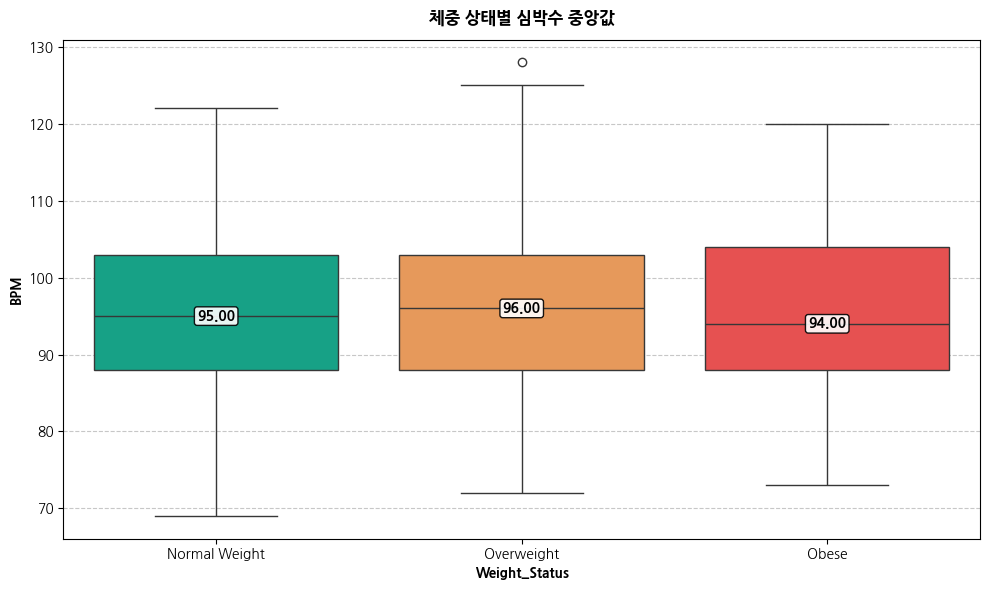

In [39]:
plot_boxplot(train, col='BPM', x_col='Weight_Status', title='체중 상태별 심박수 중앙값', palette=['#00b894', '#fd9644', '#ff3838'], figsize=(10, 6))

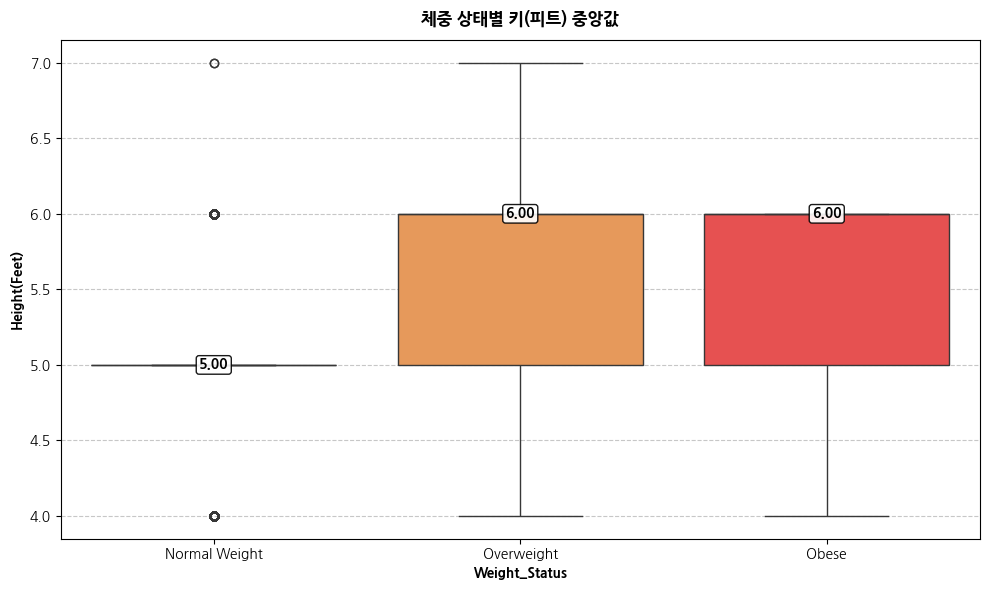

In [40]:
plot_boxplot(train, col='Height(Feet)', x_col='Weight_Status', title='체중 상태별 키(피트) 중앙값', palette=['#00b894', '#fd9644', '#ff3838'], figsize=(10, 6))

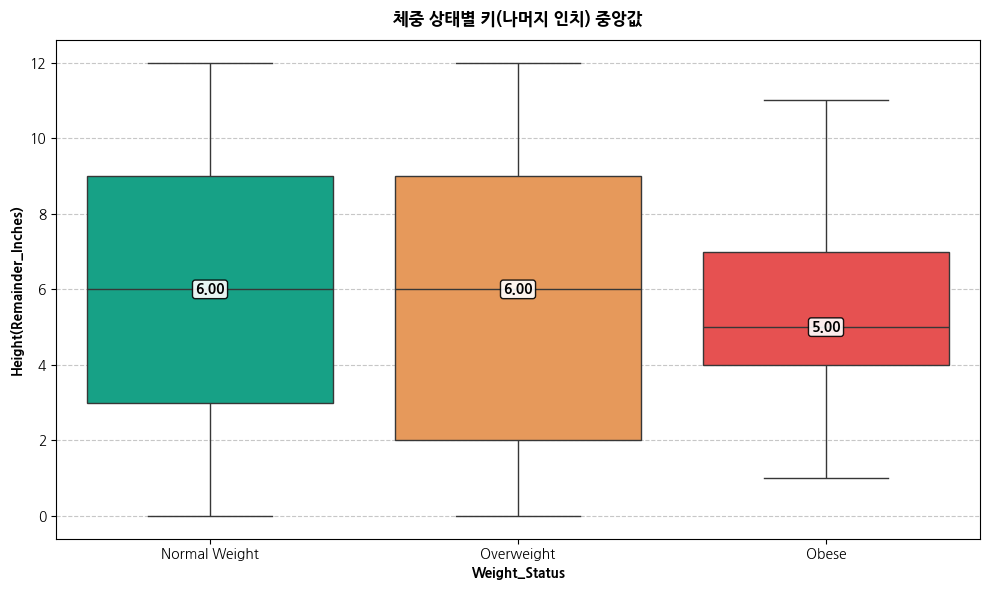

In [41]:
plot_boxplot(train, col='Height(Remainder_Inches)', x_col='Weight_Status', title='체중 상태별 키(나머지 인치) 중앙값', palette=['#00b894', '#fd9644', '#ff3838'], figsize=(10, 6))

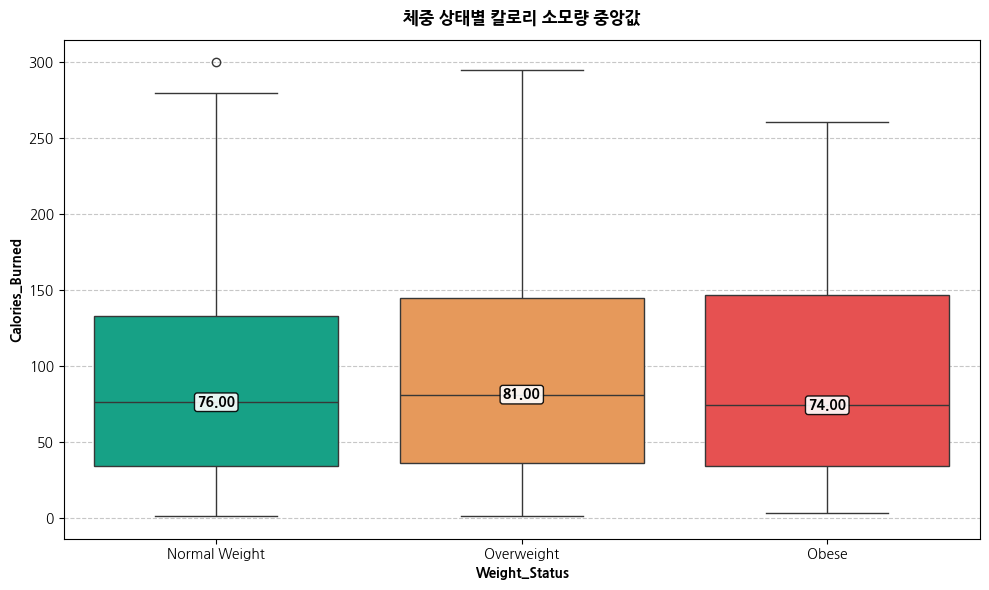

In [42]:
plot_boxplot(train, col='Calories_Burned', x_col='Weight_Status', title='체중 상태별 칼로리 소모량 중앙값', palette=['#00b894', '#fd9644', '#ff3838'], figsize=(10, 6))

# Feature Engineering / 기존 데이터를 변형, 결합, 혹은 계산하여 새로운 변수를 만들기

In [43]:
# Train 데이터 기준으로 구간(Threshold) 미리 계산 (Test에도 동일 기준 적용 위함)
# 1. BPM Multiplier용 기준 (0.2, 0.4, 0.6, 0.8)
bpm_q_thresholds = train['BPM'].quantile([0.2, 0.4, 0.6, 0.8]).values

# 2. Intensity_Level용 기준 (4등분)
bpm_bins = train['BPM'].quantile([0, 0.25, 0.5, 0.75, 1.0]).values
bpm_bins[0] = -np.inf  # 최소값 처리
bpm_bins[-1] = np.inf  # 최대값 처리

# 3. Duration_Category용 기준 (3등분)
duration_bins = train['Exercise_Duration'].quantile([0, 1/3, 2/3, 1.0]).values
duration_bins[0] = -np.inf
duration_bins[-1] = np.inf

# 처리할 데이터프레임 목록
df_list = [train, test]

# 학습, 테스트 데이터 모두 파생 변수 생성
for df in df_list:
    # 체중 단위를 파운드(lb)에서 킬로그램(kg)으로 변환
    df['Weight(kg)'] = df['Weight(lb)'] * 0.453592
    # 키 단위를 피트와 인치에서 센티미터(cm)로 변환
    df['Height(cm)'] = df['Height(Feet)'] * 30.48 + df['Height(Remainder_Inches)'] * 2.54
    # 키 단위를 센티미터(cm)에서 미터(m)로 변환
    df['Height(m)'] = df['Height(cm)'] / 100
    
    # BMI(체질량지수) 파생 변수 생성
    df['BMI'] = df['Weight(kg)'] / (df['Height(m)'] ** 2)
    
    # BMR 공식에 따른 기초 대사량 파생 변수 생성
    df['BMR_Harris'] = np.where(
        df['Gender'] == 'M',
        (9.65 * df['Weight(kg)']) + (573 * df['Height(m)']) - (5.08 * df['Age']) + 260,
        (7.38 * df['Weight(kg)']) + (607 * df['Height(m)']) - (2.31 * df['Age']) + 43
    )
    
    # RMR 공식에 따른 기초 대사량 파생 변수 생성
    df['RMR_Mifflin'] = np.where(
        df['Gender'] == 'M',
        (10 * df['Weight(kg)']) + (6.25 * df['Height(cm)']) - (5 * df['Age']) + 5,
        (10 * df['Weight(kg)']) + (6.25 * df['Height(cm)']) - (5 * df['Age']) - 161
    )
    
    # BPM 분포에 따른 강도 계수 파생 변수 생성
    # Train 기준값인 bpm_q_thresholds
    conditions = [ 
        df['BPM'] <= bpm_q_thresholds[0],
        df['BPM'] <= bpm_q_thresholds[1],
        df['BPM'] <= bpm_q_thresholds[2],
        df['BPM'] <= bpm_q_thresholds[3]
    ]
    choices = [1.2, 1.375, 1.55, 1.725]
    df['BPM_Multiplier'] = np.select(conditions, choices, default=1.9)
    
    # 운동 시간 동안의 이론적 소모량 파생 변수 생성
    df['Session_Harris_Calories'] = (df['BMR_Harris'] / 1440) * df['Exercise_Duration'] * df['BPM_Multiplier'] # Harris 기준 소모 칼로리
    df['Session_Mifflin_Calories'] = (df['RMR_Mifflin'] / 1440) * df['Exercise_Duration'] * df['BPM_Multiplier'] # Mifflin 기준 소모 칼로리
    
    # Keytel 기준 소모 칼로리
    df['Session_Keytel_Calories'] = np.where(
        df['Gender'] == 'M',
        ((-55.0969 + (0.6309 * df['BPM']) + (0.1988 * df['Weight(kg)']) + (0.2017 * df['Age'])) / 4.184) * df['Exercise_Duration'],
        ((-20.4022 + (0.4472 * df['BPM']) - (0.1263 * df['Weight(kg)']) + (0.074 * df['Age'])) / 4.184) * df['Exercise_Duration']
    )
    
    # 실제 소모량 대비 이론적 소모량 비율 파생 변수 생성
    if 'Calories_Burned' in df.columns:
        df['Actual_vs_Harris'] = df['Calories_Burned'] / df['Session_Harris_Calories'] # Harris 기준 효율 지수
        df['Actual_vs_Mifflin'] = df['Calories_Burned'] / df['Session_Mifflin_Calories'] # Mifflin 기준 효율 지수
        df['Actual_vs_Keytel'] = df['Calories_Burned'] / df['Session_Keytel_Calories'] # Keytel 기준 효율 지수
    
    # 나이대 카테고리 파생 변수 생성
    df['Age_Range'] = pd.cut(
        df['Age'], 
        bins=[0, 29, 39, 49, 59, 69, 100], 
        labels=['20s', '30s', '40s', '50s', '60s', '70s+'],
        right=True
    )
    
    # 운동 강도 카테고리 파생 변수 생성
    # Train 기준 bpm_bins 적용
    df['Intensity_Level'] = pd.cut(
        df['BPM'], 
        bins=bpm_bins, 
        labels=['Low', 'Moderate', 'High', 'Extreme']
    )
    
    # 운동 시간 카테고리 파생 변수 생성
    # Train 기준 duration_bins 적용
    df['Duration_Category'] = pd.cut(
        df['Exercise_Duration'], 
        bins=duration_bins, 
        labels=['Short', 'Medium', 'Long']
    )
    
    # 운동 세션 카테고리 파생 변수 생성
    df['Session_Type'] = np.select(
        [
            (df['Exercise_Duration'] <= 15) & (df['BPM'] <= 95),
            (df['Exercise_Duration'] <= 15) & (df['BPM'] > 95),
            (df['Exercise_Duration'] > 15) & (df['BPM'] <= 95),
            (df['Exercise_Duration'] > 15) & (df['BPM'] > 95)
        ],
        ['WarmUp', 'Power_Short', 'Endurance_Long', 'Athletic_Long'],
        default='General'
    )
        
    BASELINE_TEMP = 98.6
    
    # 초과 체온 파생 변수 생성
    df['Temp_Excess'] = df['Body_Temperature(F)'] - BASELINE_TEMP
    
    # 열 생성률(시간당 온도 상승 속도) 파생 변수 생성
    df['Thermal_Intensity'] = df['Temp_Excess'] / (df['Exercise_Duration'] + 1e-5)
    
    # 체질량 열에너지(체중 * 온도상승분) 파생 변수 생성
    df['Heat_Energy_Proxy'] = df['Weight(kg)'] * df['Temp_Excess']
    
    # (고열 구간(104도 이상) 파생 변수 생성
    df['Is_Overheat'] = (df['Body_Temperature(F)'] >= 104).astype(int)

print(train.columns)
print(test.columns)

Index(['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)',
       'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender',
       'Age', 'Calories_Burned', 'Weight(kg)', 'Height(cm)', 'Height(m)',
       'BMI', 'BMR_Harris', 'RMR_Mifflin', 'BPM_Multiplier',
       'Session_Harris_Calories', 'Session_Mifflin_Calories',
       'Session_Keytel_Calories', 'Actual_vs_Harris', 'Actual_vs_Mifflin',
       'Actual_vs_Keytel', 'Age_Range', 'Intensity_Level', 'Duration_Category',
       'Session_Type', 'Temp_Excess', 'Thermal_Intensity', 'Heat_Energy_Proxy',
       'Is_Overheat'],
      dtype='object')
Index(['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)',
       'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender',
       'Age', 'Weight(kg)', 'Height(cm)', 'Height(m)', 'BMI', 'BMR_Harris',
       'RMR_Mifflin', 'BPM_Multiplier', 'Session_Harris_Calories',
       'Session_Mifflin_Calories', 'Session_Keytel_Calories', 'Age_R

In [44]:
print(test['Intensity_Level'].value_counts(normalize=True).sort_index())

Intensity_Level
Low         0.252667
Moderate    0.241200
High        0.276933
Extreme     0.229200
Name: proportion, dtype: float64


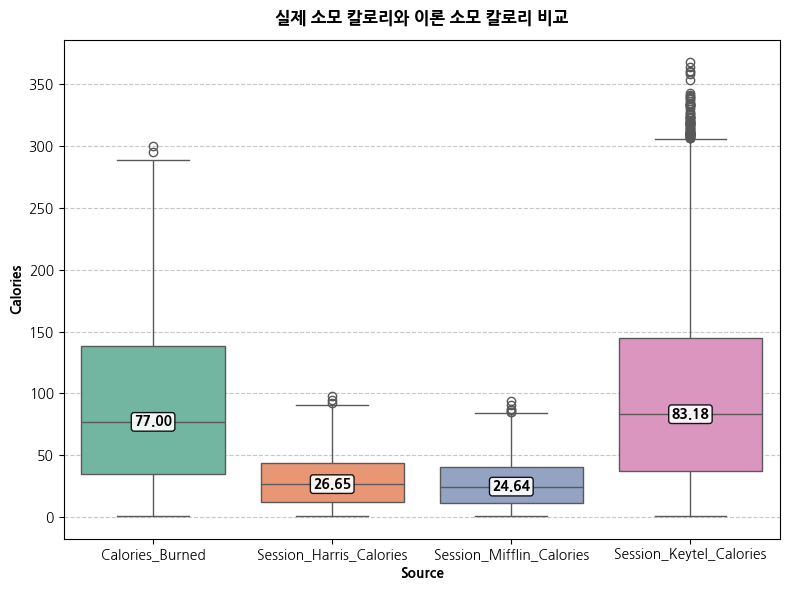

In [45]:
comparison_df = train[['Calories_Burned', 'Session_Harris_Calories', 'Session_Mifflin_Calories', 'Session_Keytel_Calories']].melt(
    var_name='Source', value_name='Calories'
)

plot_boxplot(
    df=comparison_df, 
    col='Calories', 
    x_col='Source', 
    title='실제 소모 칼로리와 이론 소모 칼로리 비교', 
    figsize=(8, 6), 
    palette='Set2'
)

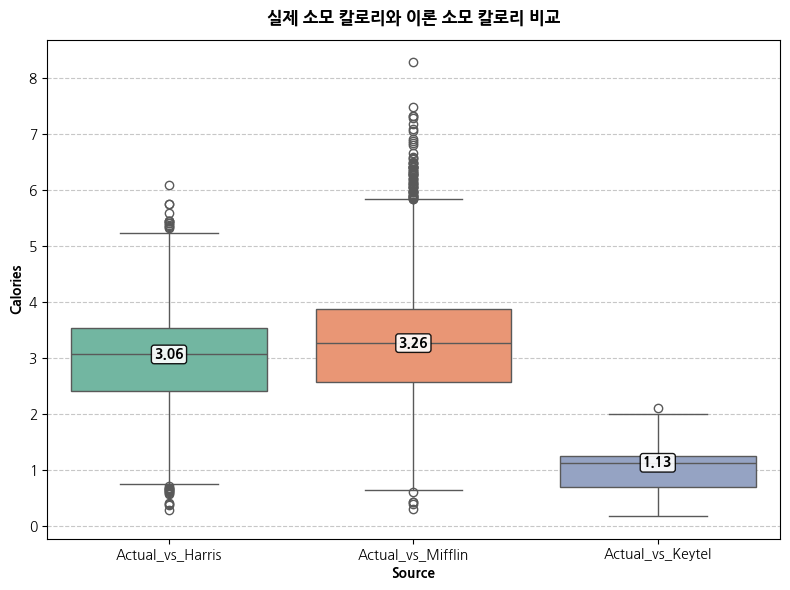

In [46]:
comparison_df = train[['Actual_vs_Harris', 'Actual_vs_Mifflin', 'Actual_vs_Keytel']].melt(
    var_name='Source', value_name='Calories'
)

plot_boxplot(
    df=comparison_df, 
    col='Calories', 
    x_col='Source', 
    title='실제 소모 칼로리와 이론 소모 칼로리 비교', 
    figsize=(8, 6), 
    palette='Set2'
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3332116624.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby(x_col)[col].median().reindex(plot_order)


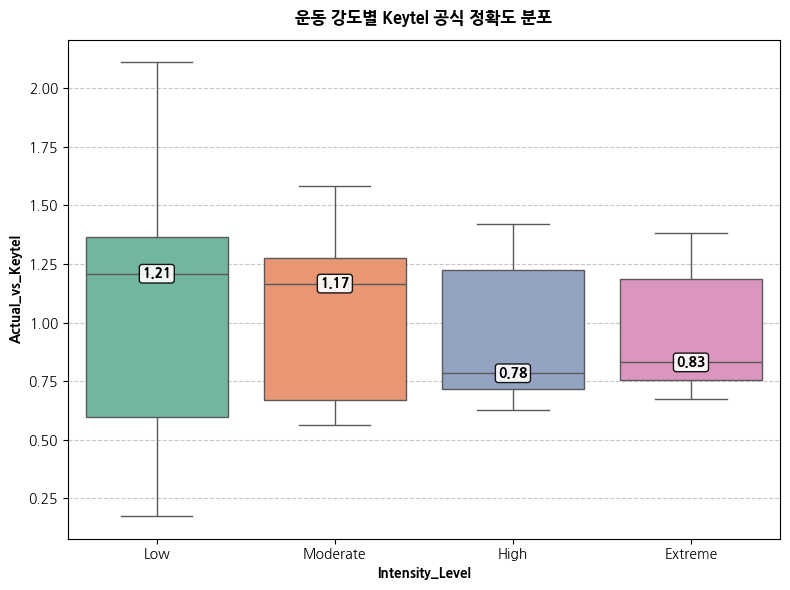

In [47]:
intensity_order = ['Low', 'Moderate', 'High', 'Extreme']

plot_boxplot(
    df=train, 
    col='Actual_vs_Keytel', 
    x_col='Intensity_Level', 
    title='운동 강도별 Keytel 공식 정확도 분포', 
    figsize=(8, 6), 
    palette='Set2',
    order=intensity_order 
)

# Scatter Plot & Trending Line / 변수들 간의 상관관계 파악하기
모델에서 주요하게 사용해야 할 특성(feature)을 확인하여야 합니다.  
따라서 각 변수와 변수의 상관관계를 파악하기 위해 점들을 나타내고 추세선을 그어봅니다.

In [48]:
def plot_scatter(df, x_col, y_col, title='', figsize=(6, 5), color='royalblue'):
    plt.figure(figsize=figsize)
    
    # 1. 회귀선이 포함된 산점도 그리기 (sns.regplot)
    # scatter_kws: 점의 투명도(alpha)와 크기(s) 조절
    # line_kws: 회귀선의 색상(red) 조절
    ax = sns.regplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        scatter_kws={'alpha': 0.3, 's': 15, 'color': color}, 
        line_kws={'color': 'red', 'linewidth': 2}
    )
    
    # 2. 상관계수(Correlation) 계산 및 텍스트 표시
    corr = df[x_col].corr(df[y_col])
    
    # 그래프 왼쪽 상단(0.05, 0.95)에 텍스트 박스 배치
    plt.text(0.05, 0.95, f'Corr: {corr:.4f}', 
             transform=ax.transAxes, # 축 기준 좌표계 사용
             fontsize=12, fontweight='bold', va='top',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))

    # 3. 스타일 꾸미기
    # title이 비어있으면 자동으로 'x vs y' 형태로 설정
    plot_title = title if title else f'{x_col} vs {y_col}'
    
    plt.title(plot_title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(x_col, fontsize=11, fontweight='bold')
    plt.ylabel(y_col, fontsize=11, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

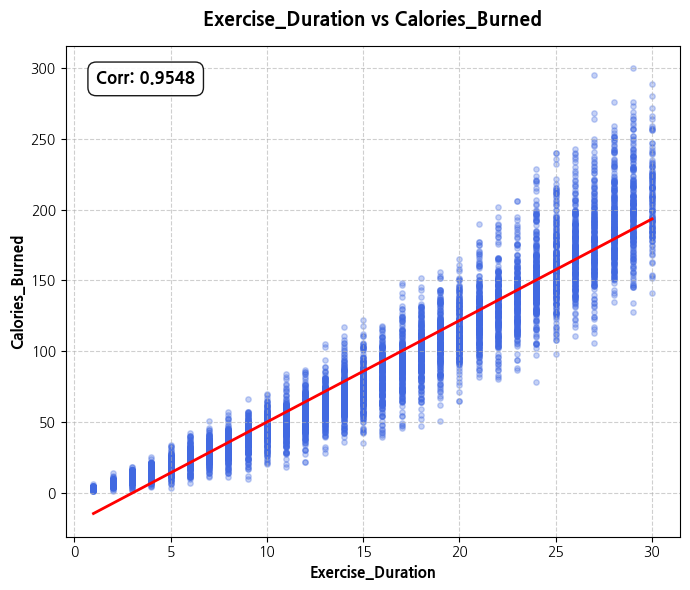

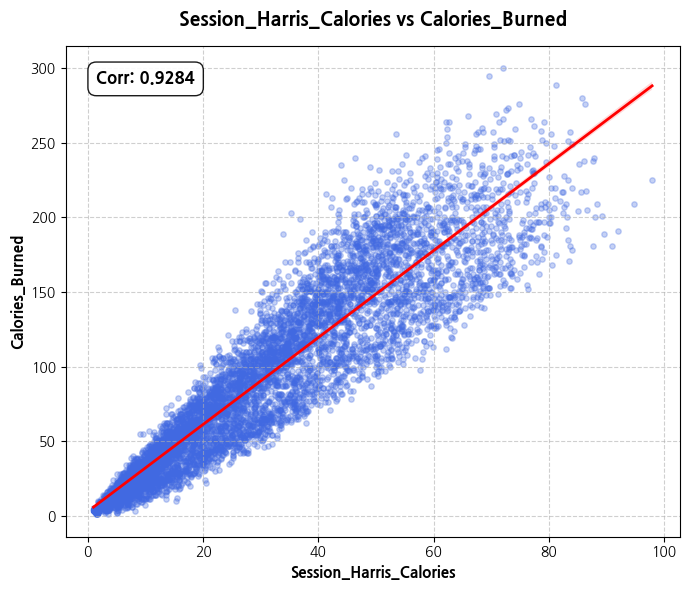

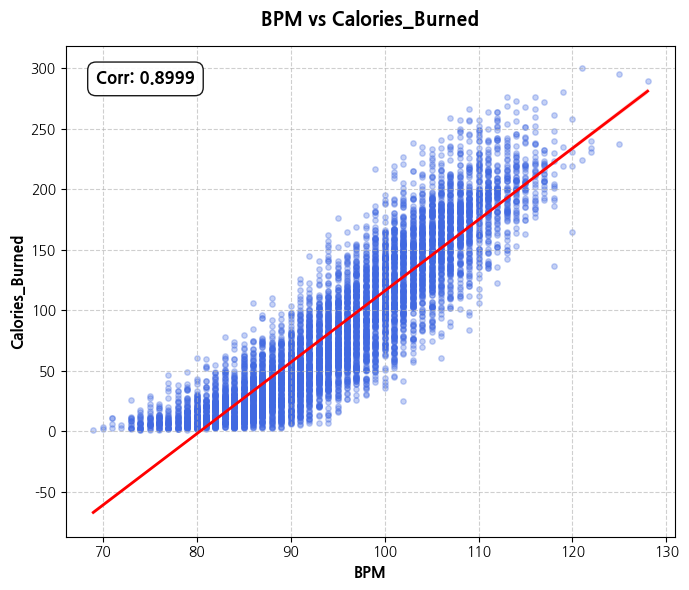

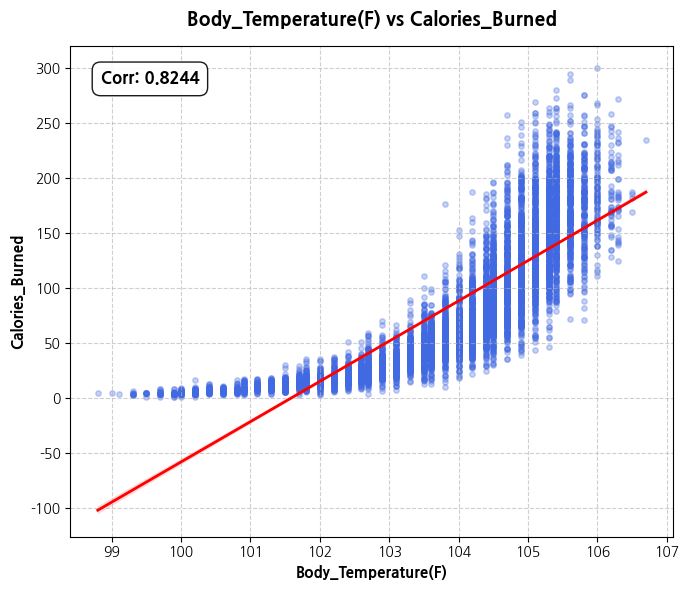

In [49]:
# 분석하고 싶은 주요 변수들 리스트
features_to_plot = [
    'Exercise_Duration', 
    'Session_Harris_Calories', 
    'BPM', 
    'Body_Temperature(F)'
]

# 반복문으로 함수 호출
for col in features_to_plot:
    plot_scatter(
        df=train,
        x_col=col, 
        y_col='Calories_Burned',
        figsize=(7, 6),  # 크기는 적당히 조절 가능
        color='royalblue'
    )

# Heatmap / 변수들 간의 상관관계 파악하기
모델에서 주요하게 사용해야 할 특성(feature)을 확인하여야 합니다.  
따라서 각 변수와 변수의 상관관계를 색상과 수치를 표시하는 행렬로 나타냅니다.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\2157249060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


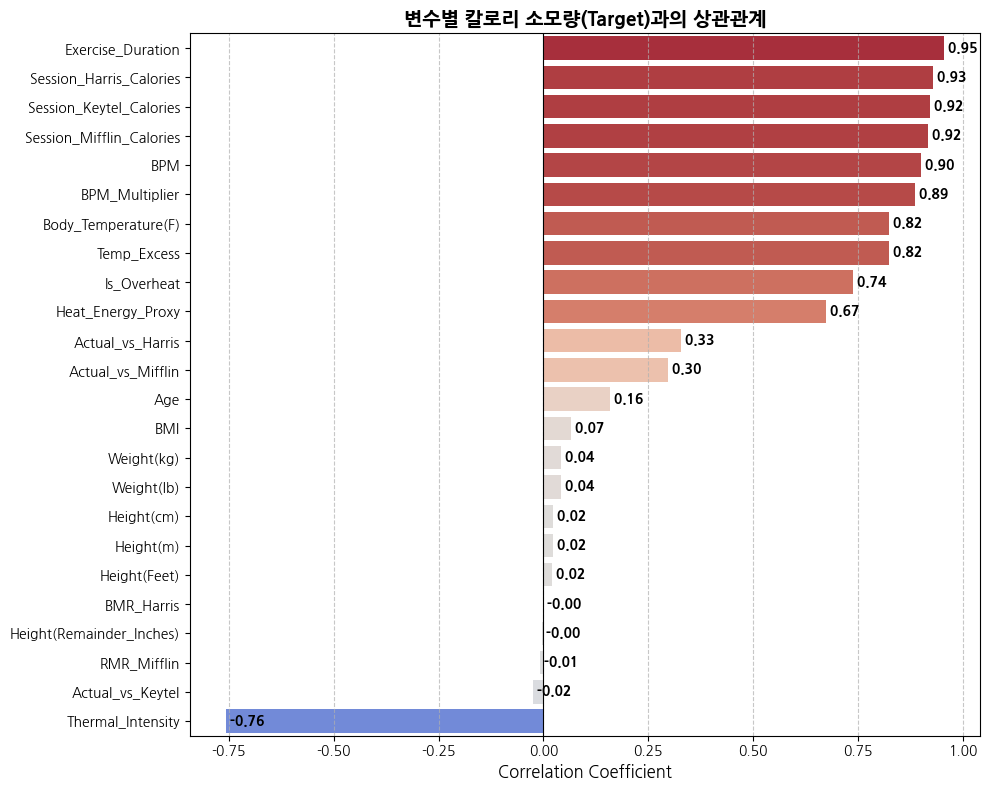

In [50]:
# 1. 데이터 준비
numeric_df = train.select_dtypes(include=['number'])
target_corr = numeric_df.corrwith(train['Calories_Burned']).sort_values(ascending=False)
target_corr = target_corr.drop('Calories_Burned')

# 2. 절대 기준(-1 ~ 1) 색상 매핑 생성
# vmin=-1, vmax=1로 설정하여 0이 정확히 흰색이 되도록 고정
norm = mcolors.Normalize(vmin=-1, vmax=1)
colors = [cm.coolwarm(norm(v)) for v in target_corr.values]

# 3. 그래프 설정 (요청하신 10x8 크기)
plt.figure(figsize=(10, 8))

# 4. 막대 그래프 그리기 
sns.barplot(
    x=target_corr.values, 
    y=target_corr.index, 
    palette=colors
)

# 5. 그래프 꾸미기
plt.title('변수별 칼로리 소모량(Target)과의 상관관계', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('') 
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 6. 수치 표시
for i, v in enumerate(target_corr.values):
    plt.text(v, i, f' {v:.2f}', va='center', fontweight='bold', fontsize=10)

# 7. 레이아웃 자동 조정
plt.tight_layout()

plt.show()

# Feature & Target Split / 독립변수, 종속변수로 나누기  

모델을 학습시키기 위해서 독립변수(x)와 종속변수(y)로 나누어야 합니다.  

단, 분석에 활용될 수 없는 ID 데이터는 제거하겠습니다.

In [51]:
print(train.info()) 

# 독립변수로 설정할 train_x에서는 종속변수를 제거합니다. 또한 분석에 활용하지 않는 ID 데이터를 제거합니다.
train_x = train.drop(['ID', 'Calories_Burned', 'Actual_vs_Harris', 'Actual_vs_Mifflin', 'Actual_vs_Keytel'], axis = 1)
# train_y 변수를 종속변수로 사용하기 위해 Calories_Burned 데이터를 지정하였습니다.
train_y = train['Calories_Burned']

# train_x 데이터와 마찬가지로 분석에 활용하지 않는 ID 데이터를 제거합니다.
test_x = test.drop(['ID'], axis = 1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   ID                        7500 non-null   object  
 1   Exercise_Duration         7500 non-null   float64 
 2   Body_Temperature(F)       7500 non-null   float64 
 3   BPM                       7500 non-null   float64 
 4   Height(Feet)              7500 non-null   float64 
 5   Height(Remainder_Inches)  7500 non-null   float64 
 6   Weight(lb)                7500 non-null   float64 
 7   Weight_Status             7500 non-null   object  
 8   Gender                    7500 non-null   object  
 9   Age                       7500 non-null   int64   
 10  Calories_Burned           7500 non-null   float64 
 11  Weight(kg)                7500 non-null   float64 
 12  Height(cm)                7500 non-null   float64 
 13  Height(m)                 7500 non-null   float6

# Train, Test Split & Data Encoding / 학습을 수행하기 위한 준비

In [52]:
# 인코딩 순서 정의
age_order = ['20s', '30s', '40s', '50s', '60s', '70s+']
intensity_order = ['Low', 'Moderate', 'High', 'Extreme']
duration_order = ['Short', 'Medium', 'Long']
session_order = ['WarmUp', 'Power_Short', 'Endurance_Long', 'Athletic_Long', 'General']
weight_order = ['Normal Weight', 'Overweight', 'Obese']

# 전체 피처 군 정의
ordinal_features = ['Age_Range', 'Intensity_Level', 'Duration_Category', 'Session_Type', 'Weight_Status']
nominal_features = ['Gender']

In [53]:
def get_preprocessor(X_train):
    # 실제 존재하는 컬럼 필터링
    ord_cols = [c for c in ordinal_features if c in X_train.columns]
    nom_cols = [c for c in nominal_features if c in X_train.columns] 
    num_cols = [c for c in X_train.columns if c not in ord_cols + nom_cols]
    
    # 순서형 인코딩 매핑
    order_map = {
        'Age_Range': age_order, 'Intensity_Level': intensity_order, 
        'Duration_Category': duration_order, 'Session_Type': session_order, 
        'Weight_Status': weight_order
    }
    categories = [order_map[c] for c in ord_cols]

    # 전처리기 반환
    return ColumnTransformer(
        transformers=[
            ('ord_cat', OrdinalEncoder(categories=categories), ord_cols),
            ('nom_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), nom_cols),
            ('num', StandardScaler(), num_cols)
        ]
    )

# Optuna Hyperparameter Tuning / Optuna를 이용한 하이퍼라미터 최적화